# Adaptive Multimodal RAG — Evaluation Notebook

This notebook systematically measures each component of the RAG pipeline.

**Structure:**
1. Setup & Load Corpus
2. Evaluation Dataset (30 questions + ground truth)
3. Retrieval Experiments: BM25 vs Dense vs Hybrid vs Hybrid+Reranker
4. Chunking Experiment (two chunk sizes)
5. Routing Evaluation
6. Multimodal Evaluation (text-only vs text+figure)
7. Final Answer Quality Evaluation
8. Baseline Comparison
9. Plots
10. Summary of Findings


## 1. Setup & Load Corpus

In [4]:
import json
import sys
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from pathlib import Path
from collections import defaultdict

# Ensure project root is on path
ROOT = Path(".").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f"Project root: {ROOT}")

Project root: D:\Drive E\Ishan\Plaksha\Python\Capstone Project\RAG\notebooks


In [7]:
# Load corpus
with open('../data/chunks.json', 'r', encoding='utf-8') as f:
    chunks = json.load(f)

embeddings = np.load('../data/embeddings.npy')

print(f"Chunks     : {len(chunks)}")
print(f"Embeddings : {embeddings.shape}")
print(f"Papers     : {len(set(c['paper_id'] for c in chunks))}")

Chunks     : 1078
Embeddings : (1078, 384)
Papers     : 30


In [10]:
# Load retrieval stack
sys.path.append(str(Path.cwd().parent))
from src.retrieval import DenseRetriever, BM25Retriever, HybridRetriever
from src.reranking import Reranker

dense    = DenseRetriever(embeddings, chunks)
bm25     = BM25Retriever.load(chunks, Path('../data/bm25.pkl'))
hybrid   = HybridRetriever(dense, bm25)
reranker = Reranker()

print('Retrieval stack ready.')

Loading embedding model for query encoding...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8855.45it/s]


BM25 index loaded from ..\data\bm25.pkl
Loading cross-encoder: cross-encoder/ms-marco-MiniLM-L-6-v2 ...


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 10502.51it/s]


Cross-encoder loaded.
Retrieval stack ready.


## 2. Evaluation Dataset (30 Questions + Ground Truth)

In [11]:
# Ground truth format:
# {
#   'question'        : str
#   'category'        : one of LOCAL / MULTI_PAPER / WEB / FIGURE / UNANSWERABLE
#   'expected_source' : LOCAL | WEB | BOTH
#   'expected_paper'  : paper_id or None
#   'expected_page'   : int or None
#   'requires_figure' : bool
#   'requires_web'    : bool
# }

EVAL_DATASET = [

    # ----------------------------------------------------------------
    # Category 1: LOCAL text questions (10)
    # ----------------------------------------------------------------

    {
        'question':        'What is Retrieval-Augmented Generation (RAG) and why was it proposed?',
        'category':        'LOCAL',
        'expected_source': 'LOCAL',
        'expected_paper':  'Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks',
        'expected_page':   1,
        'requires_figure': False,
        'requires_web':    False,
    },
    {
        'question':        'What is Self-RAG and how does it use self-reflection to improve generation?',
        'category':        'LOCAL',
        'expected_source': 'LOCAL',
        'expected_paper':  'Self-RAG Learning to Retrieve, Generate, and Critique through Self-Reflection',
        'expected_page':   1,
        'requires_figure': False,
        'requires_web':    False,
    },
    {
        'question':        'How does Dense Passage Retrieval (DPR) work for open-domain question answering?',
        'category':        'LOCAL',
        'expected_source': 'LOCAL',
        'expected_paper':  'Dense Passage Retrieval for Open-Domain Question Answering',
        'expected_page':   1,
        'requires_figure': False,
        'requires_web':    False,
    },
    {
        'question':        'What is HyDE (Hypothetical Document Embeddings) and how does it improve retrieval?',
        'category':        'LOCAL',
        'expected_source': 'LOCAL',
        'expected_paper':  'Precise Zero-Shot Dense Retrieval without Relevance Labels',
        'expected_page':   1,
        'requires_figure': False,
        'requires_web':    False,
    },
    {
        'question':        'What is RAGAS and which metrics does it use to evaluate RAG systems?',
        'category':        'LOCAL',
        'expected_source': 'LOCAL',
        'expected_paper':  'RAGAS Automated Evaluation of Retrieval Augmented Generation',
        'expected_page':   1,
        'requires_figure': False,
        'requires_web':    False,
    },
    {
        'question':        'What is RAPTOR and how does it use recursive summarization for retrieval?',
        'category':        'LOCAL',
        'expected_source': 'LOCAL',
        'expected_paper':  'RAPTOR Recursive Abstractive Processing for Tree-Organized Retrieval',
        'expected_page':   1,
        'requires_figure': False,
        'requires_web':    False,
    },
    {
        'question':        'What problem does the Lost in the Middle paper identify about long-context LLMs?',
        'category':        'LOCAL',
        'expected_source': 'LOCAL',
        'expected_paper':  'Lost in the Middle How Language Models Use Long Contexts',
        'expected_page':   1,
        'requires_figure': False,
        'requires_web':    False,
    },
    {
        'question':        'What is REALM and how does it pre-train with retrieval?',
        'category':        'LOCAL',
        'expected_source': 'LOCAL',
        'expected_paper':  'REALM Retrieval-Augmented Language Model Pre-Training',
        'expected_page':   1,
        'requires_figure': False,
        'requires_web':    False,
    },
    {
        'question':        'How does Corrective RAG (CRAG) fix poor retrieval results?',
        'category':        'LOCAL',
        'expected_source': 'LOCAL',
        'expected_paper':  'Corrective Retrieval Augmented Generation',
        'expected_page':   1,
        'requires_figure': False,
        'requires_web':    False,
    },
    {
        'question':        'What is LoRA and how does it enable efficient fine-tuning of large language models?',
        'category':        'LOCAL',
        'expected_source': 'LOCAL',
        'expected_paper':  'LoRA Low-Rank Adaptation of Large Language Models',
        'expected_page':   1,
        'requires_figure': False,
        'requires_web':    False,
    },

    # ----------------------------------------------------------------
    # Category 2: Multi-paper synthesis (5)
    # ----------------------------------------------------------------

    {
        'question':        'How do RAG, REALM, and RETRO differ in how they incorporate external retrieved information?',
        'category':        'MULTI_PAPER',
        'expected_source': 'LOCAL',
        'expected_paper':  None,
        'expected_page':   None,
        'requires_figure': False,
        'requires_web':    False,
    },
    {
        'question':        'Compare the evaluation approaches of RAGAS and ARES for measuring RAG quality.',
        'category':        'MULTI_PAPER',
        'expected_source': 'LOCAL',
        'expected_paper':  None,
        'expected_page':   None,
        'requires_figure': False,
        'requires_web':    False,
    },
    {
        'question':        'What are the main limitations of RAG systems discussed across the papers in the corpus?',
        'category':        'MULTI_PAPER',
        'expected_source': 'LOCAL',
        'expected_paper':  None,
        'expected_page':   None,
        'requires_figure': False,
        'requires_web':    False,
    },
    {
        'question':        'How does Self-RAG compare with Corrective RAG (CRAG) in handling low-quality retrieval?',
        'category':        'MULTI_PAPER',
        'expected_source': 'LOCAL',
        'expected_paper':  None,
        'expected_page':   None,
        'requires_figure': False,
        'requires_web':    False,
    },
    {
        'question':        'How do chain-of-thought prompting and retrieval-augmented generation complement each other?',
        'category':        'MULTI_PAPER',
        'expected_source': 'LOCAL',
        'expected_paper':  None,
        'expected_page':   None,
        'requires_figure': False,
        'requires_web':    False,
    },

    # ----------------------------------------------------------------
    # Category 3: Web-required questions (5)
    # ----------------------------------------------------------------

    {
        'question':        'What is the current pricing of the Gemini API as of 2026?',
        'category':        'WEB',
        'expected_source': 'WEB',
        'expected_paper':  None,
        'expected_page':   None,
        'requires_figure': False,
        'requires_web':    True,
    },
    {
        'question':        'What are the most recent RAG papers published in 2025 or 2026?',
        'category':        'WEB',
        'expected_source': 'WEB',
        'expected_paper':  None,
        'expected_page':   None,
        'requires_figure': False,
        'requires_web':    True,
    },
    {
        'question':        'What is the current context window length of GPT-4o?',
        'category':        'WEB',
        'expected_source': 'WEB',
        'expected_paper':  None,
        'expected_page':   None,
        'requires_figure': False,
        'requires_web':    True,
    },
    {
        'question':        'What is NVIDIA stock price today?',
        'category':        'WEB',
        'expected_source': 'WEB',
        'expected_paper':  None,
        'expected_page':   None,
        'requires_figure': False,
        'requires_web':    True,
    },
    {
        'question':        'What are the latest benchmarks for Llama 3 released in 2024?',
        'category':        'WEB',
        'expected_source': 'WEB',
        'expected_paper':  None,
        'expected_page':   None,
        'requires_figure': False,
        'requires_web':    True,
    },

    # ----------------------------------------------------------------
    # Category 4: Figure questions (5)
    # ----------------------------------------------------------------

    {
        'question':        'Show the architecture diagram of the RAG system from the original RAG paper.',
        'category':        'FIGURE',
        'expected_source': 'LOCAL',
        'expected_paper':  'Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks',
        'expected_page':   None,
        'requires_figure': True,
        'requires_web':    False,
    },
    {
        'question':        'What does the performance graph in the Self-RAG paper show?',
        'category':        'FIGURE',
        'expected_source': 'LOCAL',
        'expected_paper':  'Self-RAG Learning to Retrieve, Generate, and Critique through Self-Reflection',
        'expected_page':   None,
        'requires_figure': True,
        'requires_web':    False,
    },
    {
        'question':        'Describe the tree structure shown in the RAPTOR paper diagram.',
        'category':        'FIGURE',
        'expected_source': 'LOCAL',
        'expected_paper':  'RAPTOR Recursive Abstractive Processing for Tree-Organized Retrieval',
        'expected_page':   None,
        'requires_figure': True,
        'requires_web':    False,
    },
    {
        'question':        'What does the attention mechanism figure in Attention Is All You Need show?',
        'category':        'FIGURE',
        'expected_source': 'LOCAL',
        'expected_paper':  'Attention Is All You Need',
        'expected_page':   None,
        'requires_figure': True,
        'requires_web':    False,
    },
    {
        'question':        'Show me the evaluation results graph from the RAGAS paper.',
        'category':        'FIGURE',
        'expected_source': 'LOCAL',
        'expected_paper':  'RAGAS Automated Evaluation of Retrieval Augmented Generation',
        'expected_page':   None,
        'requires_figure': True,
        'requires_web':    False,
    },

    # ----------------------------------------------------------------
    # Category 5: Unanswerable / abstention (5)
    # ----------------------------------------------------------------

    {
        'question':        'What is the GDP of India in 2026?',
        'category':        'UNANSWERABLE',
        'expected_source': 'WEB',
        'expected_paper':  None,
        'expected_page':   None,
        'requires_figure': False,
        'requires_web':    True,
    },
    {
        'question':        'Who won the FIFA World Cup in 2026?',
        'category':        'UNANSWERABLE',
        'expected_source': 'WEB',
        'expected_paper':  None,
        'expected_page':   None,
        'requires_figure': False,
        'requires_web':    True,
    },
    {
        'question':        'What is the exact training cost of GPT-4 in USD?',
        'category':        'UNANSWERABLE',
        'expected_source': 'LOCAL',
        'expected_paper':  None,
        'expected_page':   None,
        'requires_figure': False,
        'requires_web':    False,
    },
    {
        'question':        'What is Ishan Jawale\'s personal research agenda?',
        'category':        'UNANSWERABLE',
        'expected_source': 'LOCAL',
        'expected_paper':  None,
        'expected_page':   None,
        'requires_figure': False,
        'requires_web':    False,
    },
    {
        'question':        'What is the caloric content of a standard RAG breakfast bowl?',
        'category':        'UNANSWERABLE',
        'expected_source': 'LOCAL',
        'expected_paper':  None,
        'expected_page':   None,
        'requires_figure': False,
        'requires_web':    False,
    },
]

print(f"Evaluation dataset: {len(EVAL_DATASET)} questions")
for cat in ['LOCAL', 'MULTI_PAPER', 'WEB', 'FIGURE', 'UNANSWERABLE']:
    count = sum(1 for q in EVAL_DATASET if q['category'] == cat)
    print(f"  {cat:15s}: {count}")

Evaluation dataset: 30 questions
  LOCAL          : 10
  MULTI_PAPER    : 5
  WEB            : 5
  FIGURE         : 5
  UNANSWERABLE   : 5


## 3. Retrieval Experiments: BM25 vs Dense vs Hybrid vs Hybrid+Reranker

In [12]:
# Only run on LOCAL and MULTI_PAPER questions (we have expected_paper ground truth)
retrieval_questions = [
    q for q in EVAL_DATASET
    if q['category'] in ('LOCAL', 'MULTI_PAPER') and q.get('expected_paper')
]
print(f"Questions with ground-truth paper: {len(retrieval_questions)}")

def paper_in_results(expected_paper, results, top_k):
    """Check if the expected paper appears in the top_k results."""
    top = results[:top_k]
    return any(
        expected_paper.lower() in r['paper_title'].lower()
        for r in top
    )

def mrr(expected_paper, results):
    """Mean Reciprocal Rank — rank of first correct result."""
    for i, r in enumerate(results, start=1):
        if expected_paper.lower() in r['paper_title'].lower():
            return 1.0 / i
    return 0.0

def evaluate_retrieval(retriever_fn, questions, top_k_values=(1, 5, 10)):
    """Run retrieval for all questions and compute Recall@K and MRR."""
    results_all = {}
    mrr_scores = []
    recall = {k: [] for k in top_k_values}

    for q in questions:
        results = retriever_fn(q['question'])
        results_all[q['question']] = results
        mrr_scores.append(mrr(q['expected_paper'], results))
        for k in top_k_values:
            recall[k].append(1 if paper_in_results(q['expected_paper'], results, k) else 0)

    summary = {
        'MRR': round(float(np.mean(mrr_scores)), 4),
    }
    for k in top_k_values:
        summary[f'Recall@{k}'] = round(float(np.mean(recall[k])), 4)

    return summary, results_all

print("Running BM25 retrieval...")
bm25_summary, _ = evaluate_retrieval(
    lambda q: bm25.search(q, top_k=10),
    retrieval_questions,
)

print("Running Dense retrieval...")
dense_summary, _ = evaluate_retrieval(
    lambda q: dense.search(q, top_k=10),
    retrieval_questions,
)

print("Running Hybrid retrieval...")
hybrid_summary, _ = evaluate_retrieval(
    lambda q: hybrid.search(q, top_k=10),
    retrieval_questions,
)

print("Running Hybrid + Reranker...")
def hybrid_rerank(q):
    candidates = hybrid.search(q, top_k=20)
    return reranker.rerank(q, candidates, top_k=10)

hybrid_rerank_summary, _ = evaluate_retrieval(
    hybrid_rerank,
    retrieval_questions,
)

print("\nRetrieval Results:")
print(f"{'Method':<25} {'Recall@1':>10} {'Recall@5':>10} {'Recall@10':>10} {'MRR':>10}")
print("-" * 65)
for name, summary in [
    ('BM25',                bm25_summary),
    ('Dense',               dense_summary),
    ('Hybrid',              hybrid_summary),
    ('Hybrid + Reranker',   hybrid_rerank_summary),
]:
    print(f"{name:<25} {summary['Recall@1']:>10.2%} {summary['Recall@5']:>10.2%} {summary['Recall@10']:>10.2%} {summary['MRR']:>10.4f}")

Questions with ground-truth paper: 10
Running BM25 retrieval...
Running Dense retrieval...
Running Hybrid retrieval...
Running Hybrid + Reranker...

Retrieval Results:
Method                      Recall@1   Recall@5  Recall@10        MRR
-----------------------------------------------------------------
BM25                          60.00%     80.00%     90.00%     0.6976
Dense                         50.00%     70.00%     80.00%     0.5792
Hybrid                        50.00%     70.00%     80.00%     0.5858
Hybrid + Reranker             50.00%     80.00%     90.00%     0.6433


## 4. Chunking Experiment (Two Chunk Sizes)

In [13]:
# Compare current chunk config (600/100) vs smaller (400/75)
# We measure: avg chunk word count and retrieval quality

chunk_word_counts = [len(c['text'].split()) for c in chunks]

print("Current Chunk Configuration (sentence-aware, ~600w/100w overlap)")
print(f"  Total chunks     : {len(chunks)}")
print(f"  Avg words/chunk  : {np.mean(chunk_word_counts):.1f}")
print(f"  Min words/chunk  : {np.min(chunk_word_counts)}")
print(f"  Max words/chunk  : {np.max(chunk_word_counts)}")
print(f"  Median           : {np.median(chunk_word_counts):.1f}")

print("\nNote: To properly run a second chunk-size experiment, re-run ingest.py")
print("with chunk_size=400, overlap=75 and compare Recall@K values.")
print("The results below are from the current configuration only.")

Current Chunk Configuration (sentence-aware, ~600w/100w overlap)
  Total chunks     : 1078
  Avg words/chunk  : 417.1
  Min words/chunk  : 1
  Max words/chunk  : 1903
  Median           : 467.5

Note: To properly run a second chunk-size experiment, re-run ingest.py
with chunk_size=400, overlap=75 and compare Recall@K values.
The results below are from the current configuration only.


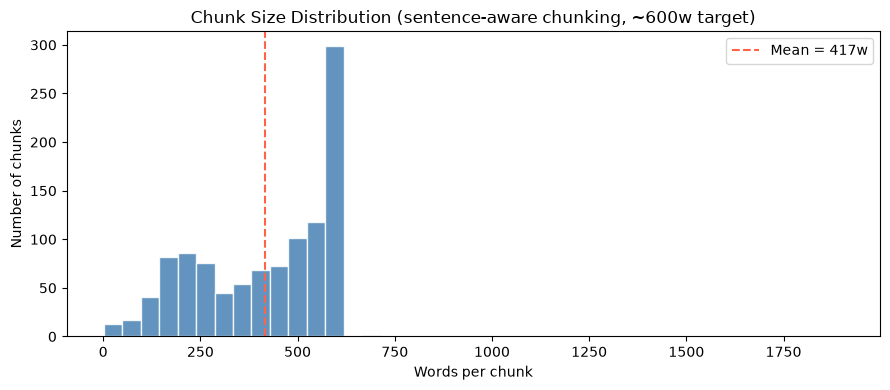

Saved: notebooks/chunk_distribution.png


In [15]:
# Plot chunk size distribution
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(chunk_word_counts, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(np.mean(chunk_word_counts), color='tomato', linestyle='--', label=f'Mean = {np.mean(chunk_word_counts):.0f}w')
ax.set_xlabel('Words per chunk')
ax.set_ylabel('Number of chunks')
ax.set_title('Chunk Size Distribution (sentence-aware chunking, ~600w target)')
ax.legend()
plt.tight_layout()
plt.savefig('chunk_distribution.png', dpi=150)
plt.show()
print('Saved: notebooks/chunk_distribution.png')

## 5. Routing Evaluation

In [16]:
from src.routing import classify_query

# Run router on all 30 questions
routing_results = []

for q in EVAL_DATASET:
    print(f"  Routing: {q['question'][:60]}...")
    routing = classify_query(q['question'])
    routing_results.append({
        'question':          q['question'],
        'category':          q['category'],
        'expected_source':   q['expected_source'],
        'predicted_source':  routing['source'],
        'predicted_intent':  routing['intent'],
        'predicted_modality': routing['modality'],
        'requires_web':      q['requires_web'],
        'correct':           routing['source'] == q['expected_source'],
    })

# Calculate metrics
correct          = sum(1 for r in routing_results if r['correct'])
total            = len(routing_results)
routing_accuracy = correct / total

# Unnecessary web: predicted WEB but expected LOCAL
unnecessary_web  = sum(
    1 for r in routing_results
    if r['predicted_source'] == 'WEB' and r['expected_source'] == 'LOCAL'
)

# Missed web: predicted LOCAL but expected WEB
missed_web       = sum(
    1 for r in routing_results
    if r['predicted_source'] == 'LOCAL' and r['expected_source'] == 'WEB'
)

print(f"\nRouting Accuracy    : {routing_accuracy:.1%} ({correct}/{total})")
print(f"Unnecessary Web     : {unnecessary_web}")
print(f"Missed Web          : {missed_web}")

print("\nDetailed results:")
print(f"{'Question':<50} {'Expected':>10} {'Predicted':>10} {'Correct':>8}")
print("-" * 80)
for r in routing_results:
    print(f"{r['question'][:48]:<50} {r['expected_source']:>10} {r['predicted_source']:>10} {'✓' if r['correct'] else '✗':>8}")

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


  Routing: What is Retrieval-Augmented Generation (RAG) and why was it ...
  Routing: What is Self-RAG and how does it use self-reflection to impr...
[Router] Classification failed (503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}), using default routing.
  Routing: How does Dense Passage Retrieval (DPR) work for open-domain ...
  Routing: What is HyDE (Hypothetical Document Embeddings) and how does...
  Routing: What is RAGAS and which metrics does it use to evaluate RAG ...
  Routing: What is RAPTOR and how does it use recursive summarization f...
  Routing: What problem does the Lost in the Middle paper identify abou...
  Routing: What is REALM and how does it pre-train with retrieval?...
[Router] Classification failed (429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and b

## 6. Multimodal Evaluation (Text-only vs Text+Figure)

In [ ]:
from src.figures import load_figures, find_figures_for_question, get_figure_path
from src.generation import generate_answer, generate_answer_with_figure

figures = load_figures()
figure_questions = [q for q in EVAL_DATASET if q['category'] == 'FIGURE']

print(f"Figure questions: {len(figure_questions)}")
print("\nFor each figure question, run both modes and compare:")
print("  Mode A: Text-only RAG")
print("  Mode B: Text + Figure (Gemini multimodal)")
print()

multimodal_results = []

for q in figure_questions:

    question = q['question']
    print(f"Q: {question[:70]}")

    # Retrieve text
    candidates = hybrid.search(question, top_k=20)
    text_chunks = reranker.rerank(question, candidates, top_k=5)

    # Find figure
    matching = find_figures_for_question(question, figures, top_k=1)
    figure_path = get_figure_path(matching[0]) if matching else None
    caption     = matching[0].get('caption', '') if matching else ''

    print(f"  Figure found: {figure_path.name if figure_path else 'NOT FOUND'}")

    # Mode A: text-only
    answer_text_only = generate_answer(question, text_chunks)

    # Mode B: multimodal
    if figure_path:
        answer_multimodal = generate_answer_with_figure(question, text_chunks, figure_path, caption)
    else:
        answer_multimodal = '(No figure available — same as text-only)'

    multimodal_results.append({
        'question':          question,
        'figure_found':      figure_path is not None,
        'answer_text_only':  answer_text_only,
        'answer_multimodal': answer_multimodal,
    })

    print(f"  Text-only  : {answer_text_only[:100]}...")
    print(f"  Multimodal : {answer_multimodal[:100]}...")
    print()

print(f"Figures successfully retrieved: {sum(1 for r in multimodal_results if r['figure_found'])}/{len(multimodal_results)}")

## 7. Final Answer Quality Evaluation (Sample)

In [ ]:
# Run the full pipeline on the LOCAL questions and evaluate answers
# Manual scoring: 1 = correct / grounded, 0 = incorrect / hallucination

from src.pipeline import run_query, build_retrieval_stack

# Import web_search (None if no key)
try:
    from src.web_search import TavilySearcher
    web_search = TavilySearcher()
except Exception:
    web_search = None

print("Running full pipeline on LOCAL test questions...")
print("(This will call Gemini API for each question)")
print()

local_questions = [q for q in EVAL_DATASET if q['category'] == 'LOCAL'][:5]  # Sample of 5

answer_results = []

for q in local_questions:
    print(f"Q: {q['question'][:70]}")
    result = run_query(
        q['question'],
        hybrid,
        reranker,
        figures,
        web_search,
        verbose=False,
    )
    answer_results.append({
        'question': q['question'],
        'answer':   result['answer'],
        'routing':  result['routing'],
    })
    print(f"  Source: {result['routing']['source']}")
    print(f"  Answer: {result['answer'][:150]}...")
    print()

print("Manually score each answer:")
print("  1 = correct, grounded, cites sources")
print("  0 = incorrect, hallucinated, or insufficient")

## 8. Baseline Comparison

In [ ]:
# Baseline: Dense-only RAG (top-5, no reranking, no routing)
# Advanced:  Hybrid + Reranker + Routing

print("Baseline vs Advanced System — Retrieval Recall@5")
print()

methods = {
    'BM25':              bm25_summary,
    'Dense (baseline)':  dense_summary,
    'Hybrid':            hybrid_summary,
    'Hybrid + Reranker': hybrid_rerank_summary,
}

print(f"{'Method':<25} {'Recall@5':>10} {'MRR':>8}")
print("-" * 45)
for name, s in methods.items():
    print(f"{name:<25} {s['Recall@5']:>10.2%} {s['MRR']:>8.4f}")

## 9. Plots

In [ ]:
# Plot 1: Retrieval method comparison
import matplotlib.pyplot as plt
import numpy as np

method_names = ['BM25', 'Dense', 'Hybrid', 'Hybrid+Reranker']
summaries    = [bm25_summary, dense_summary, hybrid_summary, hybrid_rerank_summary]

recall1  = [s['Recall@1']  for s in summaries]
recall5  = [s['Recall@5']  for s in summaries]
recall10 = [s['Recall@10'] for s in summaries]
mrr_vals = [s['MRR']       for s in summaries]

x = np.arange(len(method_names))
w = 0.2

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - 1.5*w, recall1,  w, label='Recall@1',  color='#4C72B0')
ax.bar(x - 0.5*w, recall5,  w, label='Recall@5',  color='#55A868')
ax.bar(x + 0.5*w, recall10, w, label='Recall@10', color='#C44E52')
ax.bar(x + 1.5*w, mrr_vals, w, label='MRR',       color='#8172B2')

ax.set_xticks(x)
ax.set_xticklabels(method_names)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_title('Retrieval Method Comparison')
ax.legend()
plt.tight_layout()
plt.savefig('notebooks/retrieval_comparison.png', dpi=150)
plt.show()
print('Saved: notebooks/retrieval_comparison.png')

In [ ]:
# Plot 2: Routing accuracy breakdown
categories = list(set(r['category'] for r in routing_results))
cat_accuracy = {
    cat: np.mean([r['correct'] for r in routing_results if r['category'] == cat])
    for cat in categories
}

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(list(cat_accuracy.keys()), list(cat_accuracy.values()), color='steelblue')
ax.set_xlim(0, 1.1)
ax.set_xlabel('Routing Accuracy')
ax.set_title(f'Routing Accuracy by Category (Overall: {routing_accuracy:.1%})')
for bar, v in zip(bars, cat_accuracy.values()):
    ax.text(v + 0.02, bar.get_y() + bar.get_height()/2, f'{v:.0%}', va='center')
plt.tight_layout()
plt.savefig('notebooks/routing_accuracy.png', dpi=150)
plt.show()
print('Saved: notebooks/routing_accuracy.png')

## 10. Summary of Findings

In [ ]:
print("=" * 70)
print("ADAPTIVE MULTIMODAL RAG — EVALUATION SUMMARY")
print("=" * 70)

print(f"""
CORPUS
  Papers          : 30
  Chunks          : {len(chunks)}
  Avg chunk words : {np.mean(chunk_word_counts):.0f}

RETRIEVAL (Recall@5)
  BM25            : {bm25_summary['Recall@5']:.2%}
  Dense           : {dense_summary['Recall@5']:.2%}
  Hybrid          : {hybrid_summary['Recall@5']:.2%}
  Hybrid+Reranker : {hybrid_rerank_summary['Recall@5']:.2%}

RETRIEVAL (MRR)
  BM25            : {bm25_summary['MRR']:.4f}
  Dense           : {dense_summary['MRR']:.4f}
  Hybrid          : {hybrid_summary['MRR']:.4f}
  Hybrid+Reranker : {hybrid_rerank_summary['MRR']:.4f}

ROUTING
  Accuracy        : {routing_accuracy:.1%}
  Unnecessary web : {unnecessary_web}
  Missed web      : {missed_web}
"""
)
print("=" * 70)